# 2.3 — KPIs y Metricas de Producto

## Unidad 2: Caracteristicas de Productos de Datos

Un grafico de ventas por mes es visualizacion. Definir que la metrica que importa es la tasa de retencion a 30 dias, que si baja del 60% hay que actuar, y que el responsable es el equipo comercial — eso es un KPI.

Este notebook cubre como definir metricas que generan accion, como distinguirlas de las que solo se ven bien, y como implementar un sistema de seguimiento con Python.

### Contenido:
1. Metricas accionables vs vanidosas
2. Definir KPIs con el framework SMART
3. Implementar KPIs con pandas
4. Analisis de cohortes
5. Dashboard de seguimiento

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 11

In [27]:
# ============================================================
# DATASET DE EJEMPLO — plataforma SaaS de productos de datos
# ============================================================

# Simulamos 12 meses de datos de una plataforma que vende
# dashboards y reportes como servicio (suscripcion mensual)

np.random.seed(42)
n_clientes = 500
meses = pd.date_range('2024-01-01', periods=12, freq='MS')

# Generar clientes con fecha de registro
clientes = pd.DataFrame({
    'cliente_id': range(1, n_clientes + 1),
    'fecha_registro': np.random.choice(meses[:8], n_clientes),
    'plan': np.random.choice(['basico', 'profesional', 'enterprise'], n_clientes, p=[0.5, 0.35, 0.15]),
    'canal_adquisicion': np.random.choice(['organico', 'referido', 'publicidad', 'evento'], n_clientes, p=[0.3, 0.25, 0.3, 0.15]),
})

precios = {'basico': 50, 'profesional': 150, 'enterprise': 500}
clientes['precio_mensual'] = clientes['plan'].map(precios)

# Generar transacciones mensuales (algunos clientes cancelan)
registros = []
for _, cliente in clientes.iterrows():
    meses_activo = meses[meses >= cliente['fecha_registro']]
    prob_cancelar = {'basico': 0.08, 'profesional': 0.04, 'enterprise': 0.02}
    activo = True
    for mes in meses_activo:
        if not activo:
            break
        registros.append({
            'cliente_id': cliente['cliente_id'],
            'mes': mes,
            'plan': cliente['plan'],
            'ingreso': cliente['precio_mensual'],
            'tickets_soporte': np.random.poisson(1.5 if cliente['plan'] == 'basico' else 0.5),
            'logins': np.random.poisson(12 if cliente['plan'] != 'basico' else 5),
            'reportes_generados': np.random.poisson(8 if cliente['plan'] != 'basico' else 2),
        })
        if np.random.random() < prob_cancelar[cliente['plan']]:
            activo = False

df = pd.DataFrame(registros)
df['mes'] = pd.to_datetime(df['mes'])
df = df.merge(clientes[['cliente_id', 'fecha_registro', 'canal_adquisicion']], on='cliente_id')

print(f"Clientes: {n_clientes}")
print(f"Transacciones: {len(df)}")
print(f"Periodo: {df['mes'].min().strftime('%Y-%m')} a {df['mes'].max().strftime('%Y-%m')}")
df.head()

Clientes: 500
Transacciones: 3366
Periodo: 2024-01 a 2024-12


,cliente_id,mes,plan,ingreso,tickets_soporte,logins,reportes_generados,fecha_registro,canal_adquisicion
0,1,2024-07-01,basico,50,2,4,0,2024-07-01,organico
1,1,2024-08-01,basico,50,1,2,0,2024-07-01,organico
2,1,2024-09-01,basico,50,2,5,2,2024-07-01,organico
3,1,2024-10-01,basico,50,3,3,0,2024-07-01,organico
4,2,2024-04-01,basico,50,1,5,2,2024-04-01,evento


---
## 1. Metricas accionables vs vanidosas

Una metrica vanidosa se ve bien en una presentacion pero no dice que hacer. Una metrica accionable cambia una decision.

In [28]:
# ============================================================
# METRICA VANIDOSA: "Tenemos 500 usuarios registrados"
# ============================================================

# Esto se ve bien pero no dice nada util
# Cuantos estan activos? Cuantos pagan? Cuantos usan el producto?

total_registrados = clientes['cliente_id'].nunique()
print(f"Usuarios registrados: {total_registrados}")
print("\nEsto es una metrica vanidosa. Solo crece. No dice si el producto funciona.")

Usuarios registrados: 500

Esto es una metrica vanidosa. Solo crece. No dice si el producto funciona.


In [29]:
# ============================================================
# METRICA ACCIONABLE: "Tasa de retencion del 78% este mes"
# ============================================================

# La retencion dice cuantos clientes del mes pasado siguen este mes
# Si baja, hay que investigar por que se van
# Si sube, lo que estamos haciendo funciona

def calcular_retencion_mensual(df):
    """Calcula el porcentaje de clientes que se mantienen mes a mes."""
    meses = sorted(df['mes'].unique())
    retencion = []

    for i in range(1, len(meses)):
        mes_anterior = meses[i - 1]
        mes_actual = meses[i]

        # Clientes activos en el mes anterior
        clientes_anterior = set(df[df['mes'] == mes_anterior]['cliente_id'])
        # Clientes activos en el mes actual
        clientes_actual = set(df[df['mes'] == mes_actual]['cliente_id'])

        # Retenidos = los que estaban antes y siguen ahora
        retenidos = clientes_anterior & clientes_actual

        tasa = len(retenidos) / len(clientes_anterior) * 100 if clientes_anterior else 0

        retencion.append({
            'mes': mes_actual,
            'clientes_anterior': len(clientes_anterior),
            'retenidos': len(retenidos),
            'perdidos': len(clientes_anterior) - len(retenidos),
            'tasa_retencion': round(tasa, 1),
        })

    return pd.DataFrame(retencion)

df_retencion = calcular_retencion_mensual(df)
print("Retencion mensual:")
df_retencion

Retencion mensual:


,mes,clientes_anterior,retenidos,perdidos,tasa_retencion
0,2024-02-01,71,67,4,94.4
1,2024-03-01,113,108,5,95.6
2,2024-04-01,172,161,11,93.6
3,2024-05-01,237,220,17,92.8
4,2024-06-01,271,251,20,92.6
5,2024-07-01,313,296,17,94.6
6,2024-08-01,354,336,18,94.9
7,2024-09-01,408,386,22,94.6
8,2024-10-01,386,368,18,95.3
9,2024-11-01,368,347,21,94.3


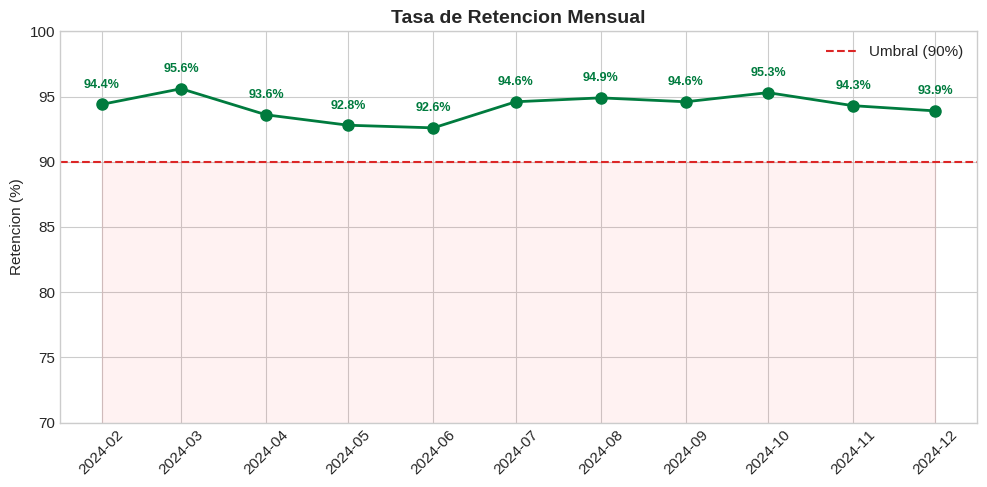


Esto es una metrica accionable:
Si la linea baja del 90%, sabemos que algo esta mal y hay que investigar.


In [30]:
# ============================================================
# VISUALIZAR RETENCION — con linea de umbral
# ============================================================

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(df_retencion['mes'], df_retencion['tasa_retencion'],
        marker='o', linewidth=2, color='#007B3E', markersize=8)

# Linea de umbral — por debajo de esto hay que actuar
ax.axhline(y=90, color='#DC2626', linestyle='--', linewidth=1.5, label='Umbral (90%)')

# Sombrear zona de peligro
ax.fill_between(df_retencion['mes'], 0, 90, alpha=0.05, color='red')

ax.set_title('Tasa de Retencion Mensual', fontsize=14, fontweight='bold')
ax.set_ylabel('Retencion (%)')
ax.set_ylim(70, 100)
ax.legend()

# Anotar el valor de cada punto
for _, row in df_retencion.iterrows():
    color = '#DC2626' if row['tasa_retencion'] < 90 else '#007B3E'
    ax.annotate(f"{row['tasa_retencion']}%",
                xy=(row['mes'], row['tasa_retencion']),
                textcoords='offset points', xytext=(0, 12),
                ha='center', fontsize=9, color=color, fontweight='bold')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("\nEsto es una metrica accionable:")
print("Si la linea baja del 90%, sabemos que algo esta mal y hay que investigar.")

### Comparativa

| Metrica vanidosa | Metrica accionable |
|---|---|
| Total de usuarios registrados | Tasa de retencion mensual |
| Paginas vistas | Tiempo promedio en el dashboard |
| Descargas de la app | Usuarios activos diarios (DAU) |
| Ingresos acumulados | MRR (ingreso recurrente mensual) |
| Reportes creados (total) | Reportes por usuario activo |

La diferencia: la vanidosa solo sube, la accionable puede bajar, y cuando baja te dice que hay un problema.

---
## 2. Framework SMART para KPIs

Un KPI bien definido cumple estos criterios:
- **S**pecifico: mide exactamente una cosa
- **M**edible: se puede calcular con datos reales
- **A**lcanzable: el objetivo es realista
- **R**elevante: importa para el negocio
- **T**emporal: tiene un plazo definido

In [31]:
# ============================================================
# DEFINIR KPIs PARA NUESTRO PRODUCTO DE DATOS
# ============================================================

kpis = pd.DataFrame([
    {
        'kpi': 'MRR (Monthly Recurring Revenue)',
        'formula': 'Suma de ingresos de todos los clientes activos en el mes',
        'umbral': '> $30,000',
        'frecuencia': 'Mensual',
        'responsable': 'Equipo comercial',
        'accion_si_falla': 'Revisar churn y adquisicion',
    },
    {
        'kpi': 'Tasa de retencion',
        'formula': 'Clientes que siguen activos / clientes del mes anterior * 100',
        'umbral': '> 90%',
        'frecuencia': 'Mensual',
        'responsable': 'Customer Success',
        'accion_si_falla': 'Encuesta de salida, mejorar onboarding',
    },
    {
        'kpi': 'Tasa de churn',
        'formula': 'Clientes que cancelaron / clientes activos inicio mes * 100',
        'umbral': '< 5%',
        'frecuencia': 'Mensual',
        'responsable': 'Customer Success',
        'accion_si_falla': 'Analizar por plan y canal, contactar clientes en riesgo',
    },
    {
        'kpi': 'Engagement (reportes/usuario)',
        'formula': 'Promedio de reportes generados por usuario activo',
        'umbral': '> 5 reportes/mes',
        'frecuencia': 'Mensual',
        'responsable': 'Producto',
        'accion_si_falla': 'Revisar UX, agregar plantillas, tutoriales',
    },
    {
        'kpi': 'ARPU (Average Revenue Per User)',
        'formula': 'MRR / Usuarios activos',
        'umbral': '> $100',
        'frecuencia': 'Mensual',
        'responsable': 'Pricing',
        'accion_si_falla': 'Revisar mix de planes, upselling',
    },
])

kpis

,kpi,formula,umbral,frecuencia,responsable,accion_si_falla
0,MRR (Monthly Recurring Revenue),Suma de ingresos de todos los clientes activos...,"> $30,000",Mensual,Equipo comercial,Revisar churn y adquisicion
1,Tasa de retencion,Clientes que siguen activos / clientes del mes...,> 90%,Mensual,Customer Success,"Encuesta de salida, mejorar onboarding"
2,Tasa de churn,Clientes que cancelaron / clientes activos ini...,< 5%,Mensual,Customer Success,"Analizar por plan y canal, contactar clientes ..."
3,Engagement (reportes/usuario),Promedio de reportes generados por usuario activo,> 5 reportes/mes,Mensual,Producto,"Revisar UX, agregar plantillas, tutoriales"
4,ARPU (Average Revenue Per User),MRR / Usuarios activos,> $100,Mensual,Pricing,"Revisar mix de planes, upselling"


---
## 3. Implementar KPIs con pandas

In [32]:
# ============================================================
# CALCULAR TODOS LOS KPIs MES A MES
# ============================================================

def calcular_kpis_mensuales(df):
    """Calcula los KPIs principales para cada mes."""
    meses = sorted(df['mes'].unique())
    resultados = []

    for i, mes in enumerate(meses):
        datos_mes = df[df['mes'] == mes]

        # Clientes activos este mes
        activos = datos_mes['cliente_id'].nunique()

        # MRR
        mrr = datos_mes['ingreso'].sum()

        # ARPU
        arpu = mrr / activos if activos > 0 else 0

        # Engagement
        reportes_promedio = datos_mes['reportes_generados'].mean()
        logins_promedio = datos_mes['logins'].mean()

        # Tickets de soporte por usuario
        tickets_promedio = datos_mes['tickets_soporte'].mean()

        # Nuevos clientes este mes
        if i == 0:
            nuevos = activos
            retencion = 100.0
            churn = 0.0
        else:
            mes_anterior = meses[i - 1]
            clientes_anterior = set(df[df['mes'] == mes_anterior]['cliente_id'])
            clientes_actual = set(datos_mes['cliente_id'])

            nuevos = len(clientes_actual - clientes_anterior)
            retenidos = len(clientes_anterior & clientes_actual)
            perdidos = len(clientes_anterior) - retenidos

            retencion = retenidos / len(clientes_anterior) * 100 if clientes_anterior else 0
            churn = perdidos / len(clientes_anterior) * 100 if clientes_anterior else 0

        # Mix de planes
        mix = datos_mes.groupby('plan')['cliente_id'].nunique()

        resultados.append({
            'mes': mes,
            'clientes_activos': activos,
            'nuevos': nuevos,
            'mrr': mrr,
            'arpu': round(arpu, 2),
            'retencion': round(retencion, 1),
            'churn': round(churn, 1),
            'reportes_por_usuario': round(reportes_promedio, 1),
            'logins_por_usuario': round(logins_promedio, 1),
            'tickets_por_usuario': round(tickets_promedio, 2),
            'pct_enterprise': round(mix.get('enterprise', 0) / activos * 100, 1),
        })

    return pd.DataFrame(resultados)

df_kpis = calcular_kpis_mensuales(df)
df_kpis

,mes,clientes_activos,nuevos,mrr,arpu,retencion,churn,reportes_por_usuario,logins_por_usuario,tickets_por_usuario,pct_enterprise
0,2024-01-01,71,71,12150,171.13,100.0,0.0,5.4,9.0,0.87,19.7
1,2024-02-01,113,46,19450,172.12,94.4,5.6,5.0,9.3,0.98,19.5
2,2024-03-01,172,64,27700,161.05,95.6,4.4,4.8,8.7,0.88,17.4
3,2024-04-01,237,76,35950,151.69,93.6,6.4,5.2,8.5,1.02,15.2
4,2024-05-01,271,51,42250,155.90,92.8,7.2,4.7,8.7,0.88,16.2
5,2024-06-01,313,62,49900,159.42,92.6,7.4,5.2,8.4,0.89,16.3
6,2024-07-01,354,58,58800,166.10,94.6,5.4,5.1,8.8,0.90,17.5
7,2024-08-01,408,72,66100,162.01,94.9,5.1,5.2,8.7,0.93,16.7
8,2024-09-01,386,0,64400,166.84,94.6,5.4,5.3,8.7,0.88,17.6
9,2024-10-01,368,0,62000,168.48,95.3,4.7,5.3,8.9,0.92,17.9


In [33]:
# ============================================================
# EVALUAR KPIs CONTRA UMBRALES
# ============================================================

def evaluar_kpis(row):
    """Evalua si los KPIs del mes cumplen los umbrales."""
    resultados = {}
    resultados['mrr_ok'] = row['mrr'] > 30000
    resultados['retencion_ok'] = row['retencion'] > 90
    resultados['churn_ok'] = row['churn'] < 5
    resultados['engagement_ok'] = row['reportes_por_usuario'] > 5
    resultados['arpu_ok'] = row['arpu'] > 100
    return pd.Series(resultados)

# Aplicar evaluacion al ultimo mes
ultimo_mes = df_kpis.iloc[-1]
evaluacion = evaluar_kpis(ultimo_mes)

print(f"Evaluacion del ultimo mes ({ultimo_mes['mes'].strftime('%Y-%m')}):")
print(f"  MRR: ${ultimo_mes['mrr']:,.0f} {'OK' if evaluacion['mrr_ok'] else 'ALERTA'}")
print(f"  Retencion: {ultimo_mes['retencion']}% {'OK' if evaluacion['retencion_ok'] else 'ALERTA'}")
print(f"  Churn: {ultimo_mes['churn']}% {'OK' if evaluacion['churn_ok'] else 'ALERTA'}")
print(f"  Engagement: {ultimo_mes['reportes_por_usuario']} rep/usr {'OK' if evaluacion['engagement_ok'] else 'ALERTA'}")
print(f"  ARPU: ${ultimo_mes['arpu']} {'OK' if evaluacion['arpu_ok'] else 'ALERTA'}")

Evaluacion del ultimo mes (2024-12):
  MRR: $56,000 OK
  Retencion: 93.9% OK
  Churn: 6.1% ALERTA
  Engagement: 5.5 rep/usr OK
  ARPU: $171.78 OK


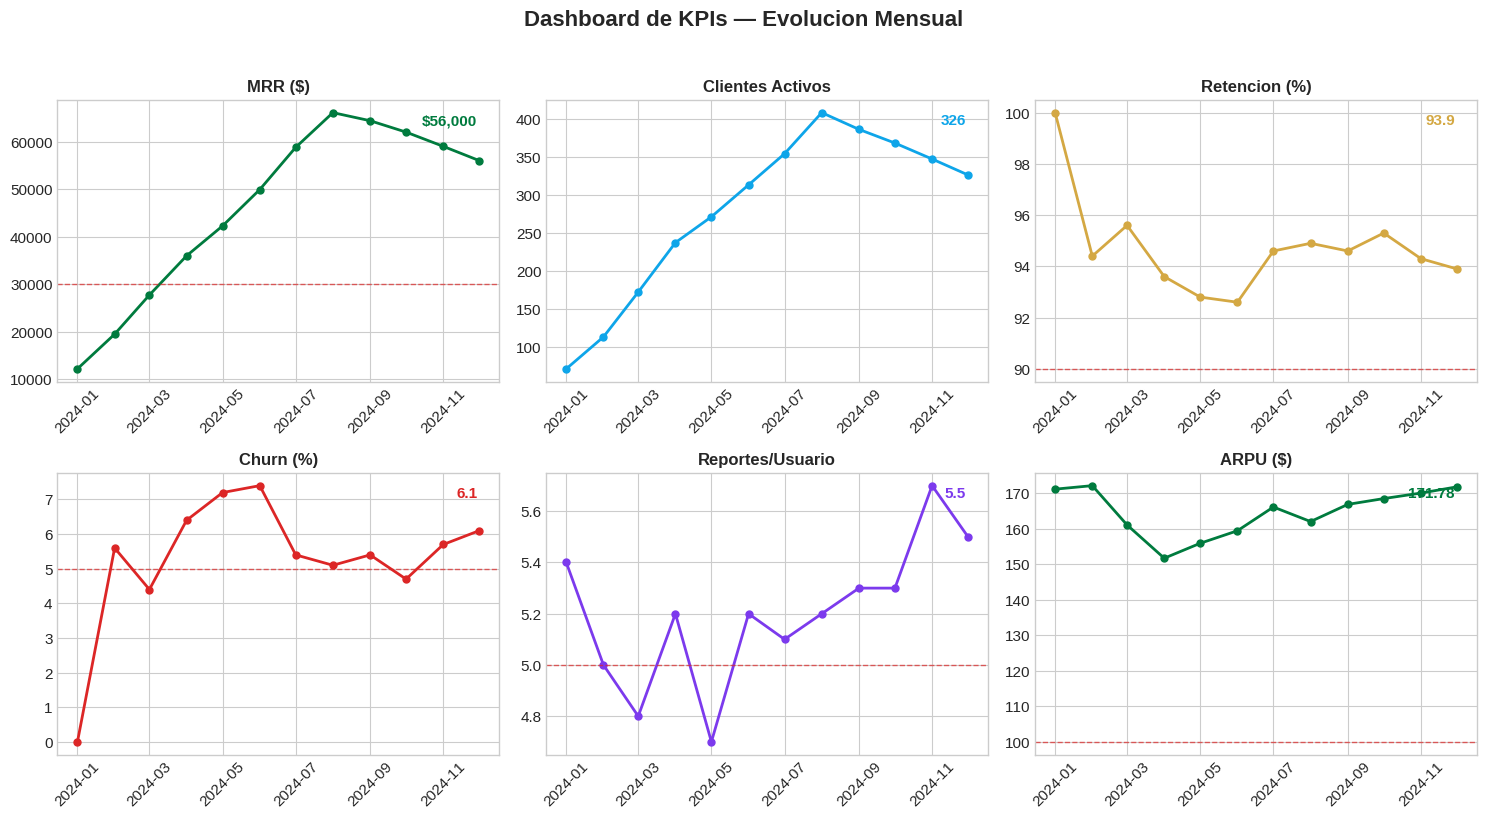

In [34]:
# ============================================================
# VISUALIZAR EVOLUCION DE KPIs
# ============================================================

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('Dashboard de KPIs — Evolucion Mensual', fontsize=16, fontweight='bold', y=1.02)

metricas = [
    ('mrr', 'MRR ($)', 30000, '#007B3E'),
    ('clientes_activos', 'Clientes Activos', None, '#0EA5E9'),
    ('retencion', 'Retencion (%)', 90, '#D4A843'),
    ('churn', 'Churn (%)', 5, '#DC2626'),
    ('reportes_por_usuario', 'Reportes/Usuario', 5, '#7C3AED'),
    ('arpu', 'ARPU ($)', 100, '#007B3E'),
]

for ax, (col, titulo, umbral, color) in zip(axes.flat, metricas):
    ax.plot(df_kpis['mes'], df_kpis[col], marker='o', color=color, linewidth=2, markersize=5)
    ax.set_title(titulo, fontsize=12, fontweight='bold')
    ax.tick_params(axis='x', rotation=45)

    if umbral is not None:
        ax.axhline(y=umbral, color='#DC2626', linestyle='--', linewidth=1, alpha=0.7)

    # Valor del ultimo mes en la esquina
    ultimo = df_kpis[col].iloc[-1]
    if col == 'mrr':
        ax.annotate(f'${ultimo:,.0f}', xy=(0.95, 0.95), xycoords='axes fraction',
                    ha='right', va='top', fontsize=11, fontweight='bold', color=color)
    else:
        ax.annotate(f'{ultimo}', xy=(0.95, 0.95), xycoords='axes fraction',
                    ha='right', va='top', fontsize=11, fontweight='bold', color=color)

plt.tight_layout()
plt.show()

---
## 4. Analisis de cohortes

Una cohorte es un grupo de clientes que comparten una caracteristica temporal — por ejemplo, todos los que se registraron en marzo. El analisis de cohortes permite ver como se comporta cada grupo a lo largo del tiempo: cuantos siguen activos despues de 1 mes, 2 meses, 6 meses.

In [35]:
# ============================================================
# CONSTRUIR TABLA DE COHORTES
# ============================================================

# Cada cohorte es el mes de registro
# Para cada cohorte, calculamos cuantos siguen activos en cada mes posterior

def tabla_cohortes(df, clientes_df):
    """
    Genera una tabla de retencion por cohorte.
    Filas: mes de registro (cohorte)
    Columnas: meses desde el registro (0, 1, 2, ...)
    Valores: porcentaje de clientes que siguen activos
    """
    # Agregar mes de registro al dataset de transacciones
    df_c = df.merge(clientes_df[['cliente_id', 'fecha_registro']], on='cliente_id')

    # Calcular meses desde el registro
    df_c['cohorte'] = df_c['fecha_registro_x'].dt.to_period('M')
    df_c['mes_periodo'] = df_c['mes'].dt.to_period('M')
    df_c['meses_desde_registro'] = (df_c['mes_periodo'] - df_c['cohorte']).apply(lambda x: x.n)

    # Contar clientes unicos por cohorte y mes
    tabla = df_c.groupby(['cohorte', 'meses_desde_registro'])['cliente_id'].nunique().reset_index()
    tabla = tabla.pivot(index='cohorte', columns='meses_desde_registro', values='cliente_id')

    # Tamano de cada cohorte (mes 0)
    tamano_cohorte = tabla[0]

    # Convertir a porcentaje
    tabla_pct = tabla.divide(tamano_cohorte, axis=0) * 100

    return tabla, tabla_pct, tamano_cohorte

tabla_abs, tabla_pct, tamanos = tabla_cohortes(df, clientes)

print("Tabla de cohortes (% de retencion):")
tabla_pct.round(0)

Tabla de cohortes (% de retencion):


meses_desde_registro,0,1,2,3,4,5,6,7,8,9,10,11
cohorte,,,,,,,,,,,,
2024-01,100.0,94.0,93.0,86.0,77.0,75.0,72.0,70.0,65.0,59.0,58.0,55.0
2024-02,100.0,91.0,89.0,83.0,80.0,80.0,76.0,70.0,67.0,65.0,61.0,NaN
2024-03,100.0,92.0,86.0,83.0,80.0,73.0,70.0,69.0,61.0,52.0,NaN,NaN
2024-04,100.0,95.0,83.0,78.0,72.0,68.0,63.0,59.0,59.0,NaN,NaN,NaN
2024-05,100.0,88.0,78.0,75.0,73.0,71.0,67.0,63.0,NaN,NaN,NaN,NaN
2024-06,100.0,94.0,85.0,82.0,81.0,74.0,73.0,NaN,NaN,NaN,NaN,NaN
2024-07,100.0,100.0,93.0,90.0,88.0,79.0,NaN,NaN,NaN,NaN,NaN,NaN
2024-08,100.0,96.0,90.0,85.0,81.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


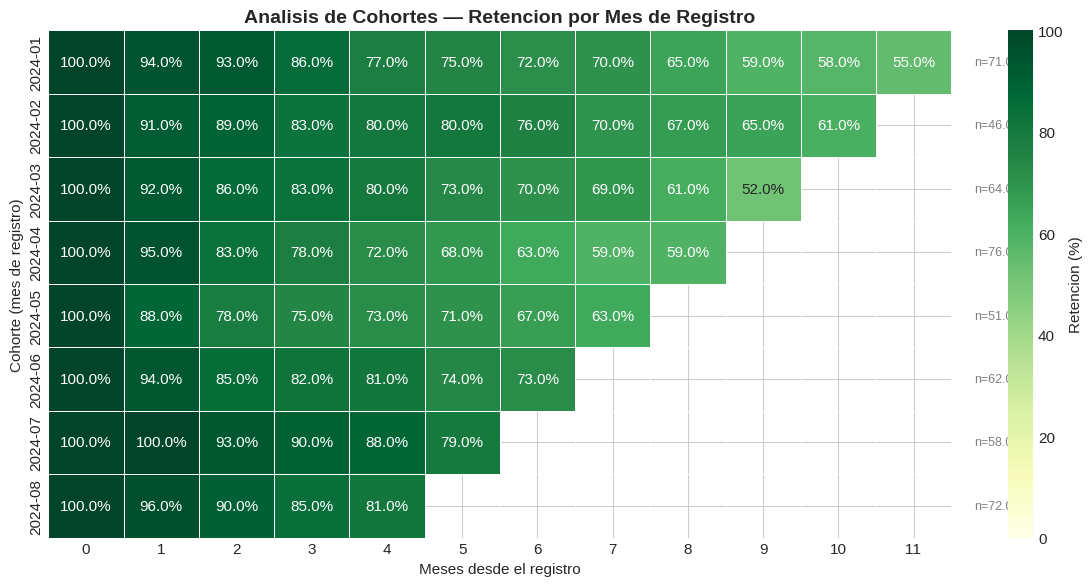


Como leer esta tabla:
  Fila: grupo de clientes que se registraron en ese mes
  Columna 0: 100% (todos empiezan activos)
  Columna 3: % que sigue activo 3 meses despues
  Si una cohorte cae rapido, algo paso en ese mes (mal onboarding, bug, etc.)


In [36]:
# ============================================================
# HEATMAP DE COHORTES
# ============================================================

fig, ax = plt.subplots(figsize=(12, 6))

# Formatear etiquetas de cohorte
labels = tabla_pct.round(0).astype(str) + '%'
labels = labels.replace('nan%', '')

sns.heatmap(
    tabla_pct,
    annot=labels,
    fmt='',
    cmap='YlGn',
    vmin=0,
    vmax=100,
    linewidths=0.5,
    ax=ax,
    cbar_kws={'label': 'Retencion (%)'}
)

ax.set_title('Analisis de Cohortes — Retencion por Mes de Registro', fontsize=14, fontweight='bold')
ax.set_xlabel('Meses desde el registro')
ax.set_ylabel('Cohorte (mes de registro)')

# Agregar tamano de cohorte a la derecha
for i, tam in enumerate(tamanos):
    ax.text(tabla_pct.shape[1] + 0.3, i + 0.5, f'n={tam}',
            va='center', fontsize=9, color='gray')

plt.tight_layout()
plt.show()

print("\nComo leer esta tabla:")
print("  Fila: grupo de clientes que se registraron en ese mes")
print("  Columna 0: 100% (todos empiezan activos)")
print("  Columna 3: % que sigue activo 3 meses despues")
print("  Si una cohorte cae rapido, algo paso en ese mes (mal onboarding, bug, etc.)")

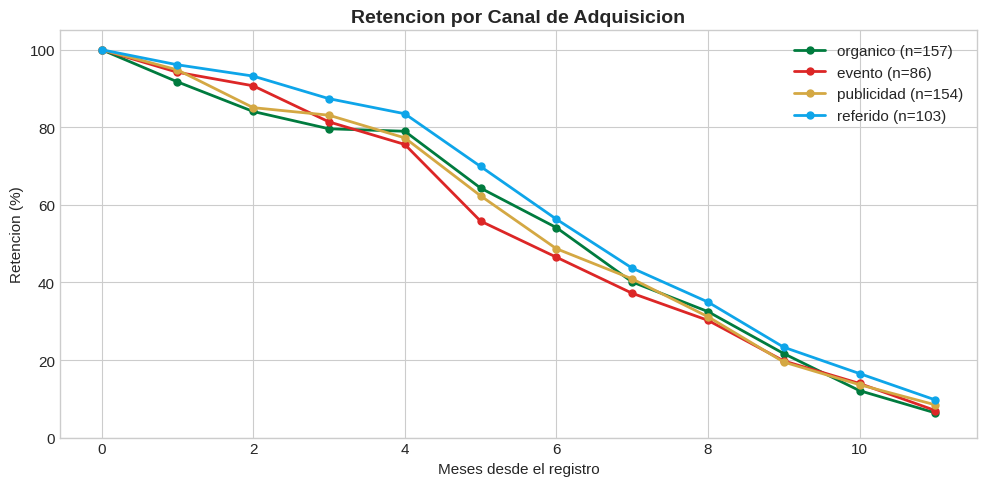


Esto es accionable: si un canal retiene peor, hay que mejorar
su onboarding o dejar de invertir en el.


In [41]:
# ============================================================
# COHORTES POR CANAL DE ADQUISICION
# ============================================================

# Pregunta: los clientes referidos retienen mejor que los de publicidad?

def retencion_por_canal(df, clientes_df):
    """Compara la retencion promedio por canal de adquisicion."""
    df_c = df.merge(clientes_df[['cliente_id', 'fecha_registro', 'canal_adquisicion']], on='cliente_id')
    df_c['cohorte'] = df_c['fecha_registro_x'].dt.to_period('M')
    df_c['mes_periodo'] = df_c['mes'].dt.to_period('M')
    df_c['meses_desde_registro'] = (df_c['mes_periodo'] - df_c['cohorte']).apply(lambda x: x.n)

    resultados = []
    for canal in df_c['canal_adquisicion_x'].unique():
        df_canal = df_c[df_c['canal_adquisicion_x'] == canal]
        total_inicio = df_canal[df_canal['meses_desde_registro'] == 0]['cliente_id'].nunique()

        for mes in sorted(df_canal['meses_desde_registro'].unique()):
            activos = df_canal[df_canal['meses_desde_registro'] == mes]['cliente_id'].nunique()
            resultados.append({
                'canal': canal,
                'mes': mes,
                'retencion': activos / total_inicio * 100 if total_inicio > 0 else 0,
                'n_clientes': total_inicio,
            })

    return pd.DataFrame(resultados)

df_canal = retencion_por_canal(df, clientes)

fig, ax = plt.subplots(figsize=(10, 5))
colores = {'organico': '#007B3E', 'referido': '#0EA5E9', 'publicidad': '#D4A843', 'evento': '#DC2626'}

for canal in df_canal['canal'].unique():
    datos = df_canal[df_canal['canal'] == canal]
    n = datos['n_clientes'].iloc[0]
    ax.plot(datos['mes'], datos['retencion'], marker='o', label=f'{canal} (n={n})',
            color=colores.get(canal, '#666'), linewidth=2, markersize=5)

ax.set_title('Retencion por Canal de Adquisicion', fontsize=14, fontweight='bold')
ax.set_xlabel('Meses desde el registro')
ax.set_ylabel('Retencion (%)')
ax.legend()
ax.set_ylim(0, 105)
plt.tight_layout()
plt.show()

print("\nEsto es accionable: si un canal retiene peor, hay que mejorar")
print("su onboarding o dejar de invertir en el.")

---
## 5. Dashboard de seguimiento

Vamos a construir una funcion que genera un reporte de KPIs con semaforo: verde si cumple, rojo si no.

In [42]:
# ============================================================
# GENERAR REPORTE DE KPIs CON SEMAFORO
# ============================================================

def reporte_kpis(df_kpis, mes=None):
    """
    Genera un reporte de KPIs para un mes especifico.
    Incluye valor actual, variacion vs mes anterior y semaforo.
    """
    if mes is None:
        idx = -1
    else:
        idx = df_kpis[df_kpis['mes'] == pd.Timestamp(mes)].index[0]

    actual = df_kpis.iloc[idx]
    anterior = df_kpis.iloc[idx - 1] if idx > 0 else actual

    umbrales = {
        'mrr': ('>', 30000),
        'retencion': ('>', 90),
        'churn': ('<', 5),
        'reportes_por_usuario': ('>', 5),
        'arpu': ('>', 100),
    }

    print(f"\n{'='*60}")
    print(f"  REPORTE DE KPIs — {actual['mes'].strftime('%B %Y')}")
    print(f"{'='*60}")

    for kpi, (operador, umbral) in umbrales.items():
        valor = actual[kpi]
        valor_ant = anterior[kpi]
        variacion = valor - valor_ant

        # Determinar semaforo
        if operador == '>':
            ok = valor > umbral
        else:
            ok = valor < umbral

        semaforo = 'OK' if ok else 'ALERTA'
        flecha = '+' if variacion > 0 else ''

        # Formatear valor
        if kpi == 'mrr':
            val_str = f"${valor:,.0f}"
            var_str = f"{flecha}${variacion:,.0f}"
            umb_str = f"> ${umbral:,}"
        elif kpi in ('retencion', 'churn'):
            val_str = f"{valor}%"
            var_str = f"{flecha}{variacion:.1f}pp"
            umb_str = f"{operador} {umbral}%"
        elif kpi == 'arpu':
            val_str = f"${valor}"
            var_str = f"{flecha}${variacion:.2f}"
            umb_str = f"> ${umbral}"
        else:
            val_str = f"{valor}"
            var_str = f"{flecha}{variacion:.1f}"
            umb_str = f"{operador} {umbral}"

        print(f"  [{semaforo:6s}] {kpi:25s}  {val_str:>12s}  ({var_str:>10s})  Umbral: {umb_str}")

    print(f"\n  Clientes activos: {int(actual['clientes_activos'])}")
    print(f"  Nuevos este mes: {int(actual['nuevos'])}")
    print(f"{'='*60}")

# Generar reporte del ultimo mes
reporte_kpis(df_kpis)


  REPORTE DE KPIs — December 2024
  [OK    ] mrr                             $56,000  (        $0)  Umbral: > $30,000
  [OK    ] retencion                         93.9%  (     0.0pp)  Umbral: > 90%
  [ALERTA] churn                              6.1%  (     0.0pp)  Umbral: < 5%
  [OK    ] reportes_por_usuario                5.5  (       0.0)  Umbral: > 5
  [OK    ] arpu                            $171.78  (     $0.00)  Umbral: > $100

  Clientes activos: 326
  Nuevos este mes: 0


In [43]:
# ============================================================
# EXPORTAR KPIs PARA DASHBOARD
# ============================================================

# Guardar la tabla de KPIs para consumir desde un dashboard
# (Streamlit, Power BI, o un reporte automatizado)

df_kpis.to_csv('kpis_mensuales.csv', index=False)
df_kpis.to_json('kpis_mensuales.json', orient='records', date_format='iso', indent=2)

print("KPIs exportados:")
print("  kpis_mensuales.csv — para Power BI o Excel")
print("  kpis_mensuales.json — para Streamlit o APIs")

KPIs exportados:
  kpis_mensuales.csv — para Power BI o Excel
  kpis_mensuales.json — para Streamlit o APIs


---
## Resumen

| Concepto | Lo que importa |
|---|---|
| **Vanidosa vs accionable** | La vanidosa solo sube, la accionable puede bajar y cuando baja te dice que hay un problema |
| **SMART** | Especifico, medible, alcanzable, relevante, temporal |
| **MRR** | Ingreso recurrente mensual — la salud financiera del producto |
| **Retencion** | Porcentaje de clientes que siguen activos — la calidad del producto |
| **Churn** | Porcentaje que cancela — el dolor del producto |
| **Cohortes** | Comparar grupos por fecha de registro para detectar tendencias |
| **Semaforo** | Valor + umbral + accion = un KPI con consecuencias |

### La regla

Si un KPI no tiene umbral y no tiene responsable, no es un KPI — es un numero.

### Siguiente paso
En el **Notebook 2.4** veremos como comunicar estos KPIs y hallazgos con storytelling: en que orden presentar, que contexto dar, como guiar al gerente desde el dato hasta la decision.